# Project - First Draft
this file is for experimenting, writing first bits of code and testing

In [1]:

# import important packages
import requests
import pandas as pd
import geopandas as gpd
import time
import matplotlib.pyplot as plt
import folium
import contextily
import cmcrameri


from cartopy import crs as ccrs
from geodatasets import get_path

In [2]:
# test my MAP_KEY

map_key = "ea49e5fe6beaf3a00954c71727386596"

import pandas as pd
import requests
key_url = f"https://firms.modaps.eosdis.nasa.gov/mapserver/mapkey_status/?map_key={map_key}"
try:
  response = requests.get(key_url)

  if response.status_code == 200:
    data = response.json()
    df = pd.Series(data)
    display(df)
  else:
    print(f"Error in the query: HTTP {response.status_code}")
    print(response.text)

  
except Exception as e:
  # possible error, wrong MAP_KEY value, check for extra quotes, missing letters
  print (f"There is an issue with the query: {e}\n try in your browser: {key_url}")
  


transaction_limit             5000
current_transactions             0
transaction_interval    10 minutes
dtype: object

### Query API and Import Data

In [3]:
import requests
import time
import datetime

# Define Dates: start and enddate format (YYYY-MM-DD), oldest date 2017?
startdate = "2023-10-22"
enddate = "2023-10-26"


type(startdate)
type(enddate)

start = pd.to_datetime(startdate)
end = pd.to_datetime(enddate)

difference = end-start
print(difference)

days = (end-start).days
print (days)


4 days 00:00:00
4


#### first try to load data

In [ ]:

import requests
import time
import datetime
import geopandas as gpd
import pandas as pd

map_key = "ea49e5fe6beaf3a00954c71727386596"

# Define Dates: start and enddate format (YYYY-MM-DD), oldest date 2017?
startdate = "2023-10-22"
enddate = "2023-10-26"

# calculate days out of dates --> FIRMS uses a number of days in the API-call
start = pd.to_datetime(startdate)
end = pd.to_datetime(enddate)

days = (end-start).days

# transform dates to FIRMS accepted format (YYYY-MM-DD)

# for loop später

#area_url = 'https://firms.modaps.eosdis.nasa.gov/api/area/csv/' + MAP_KEY + '/VIIRS_NOAA20_NRT/world/1'

#date.today() fetches the current date -> is a date-object
# srftime converts dateobject to strings as FIRMS needs it in a string format (YYYY-MM-DD)

# source for this???


# define coordinates for South America

region_coords = "-55.0,-81.5,12.5,-35.0"

# define sensor and products
sensor = "VIIRS_NOAA20_SP"
product = "fire"

# define API endpoint url

api_url = f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{map_key}/{sensor}/{region_coords}/{days}"


# define query parameters
parameters = {
    "key": map_key,
    "start_date": startdate,
    "end_date": enddate,
    "area": region_coords,
    "sensor": sensor,
    "product": product,
    "format": "csv"    
}


# fetch the data

response = requests.get(api_url, params = parameters)

# check the status and extract the data
if response.status_code == 200: 
    print("Request successful\n")

    # read url and create dataframe
    df_fire = gpd.read_file(api_url)
    print(f"\n Data download successful! {len(df_fire)} fires found")  ## NA handling??
    display(df_fire.head(6))

    # option: include a saving option if wanted
    #df_fire.to_csv("firms_data_startdate_enddate.csv", index=False) wieso index = false??

elif response.status_code == 404:
    print(f"Error 404: Page not found")

elif response.status_code == 401:
    print(f"Error 401: Invalid API-Key, please check map-key")

elif response.status_code == 400:
    print(f"Error 400: Wrong parameters, please check input parameters.")


else: 
    print(f"Request failed: Status {response.status_code}")
    print(response.text)


Error 400: Wrong parameters, please check input parameters.


#### second try to load data; works but only fetches the last 8 days

current FIRMS-URL fetches only the data for the last 8 days. It does not consider start and enddate as I calculated it. Have to create a workaround so api accepts it

In [ ]:

import requests
import time
import datetime 
import geopandas as gpd
import pandas as pd

map_key = "ea49e5fe6beaf3a00954c71727386596"

# Define Dates: start and enddate format (YYYY-MM-DD), oldest date 2017?
startdate = "2024-09-22"
enddate = "2024-09-30"

# calculate days out of dates --> FIRMS uses a number of days in the API-call
#start = pd.to_datetime(startdate)
#end = pd.to_datetime(enddate)

#days = (end-start).days 

# transform dates to FIRMS accepted format (YYYY-MM-DD)

# for loop später

#area_url = 'https://firms.modaps.eosdis.nasa.gov/api/area/csv/' + MAP_KEY + '/VIIRS_NOAA20_NRT/world/1'

#date.today() fetches the current date -> is a date-object
# srftime converts dateobject to strings as FIRMS needs it in a string format (YYYY-MM-DD)

# source for this???


# define coordinates for South America

region_coords = "-55.0,-81.5,12.5,-35.0"

# define sensor and products
sensor = "VIIRS_NOAA20_SP"
product = "fire"

# define API endpoint url

api_url = f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{map_key}/{sensor}/{region_coords}/{startdate}/{enddate}"



# fetch the data

response = requests.get(api_url)

# check the status and extract the data
if response.status_code == 200: 
    print("Request successful\n")

    # read url and create dataframe
    df_fire = pd.read_csv(api_url)
    print(f"\n Data download successful! {len(df_fire)} fires found")  ## NA handling??
    display(df_fire.head(6))

    # option: include a saving option if wanted
    #df_fire.to_csv("firms_data_startdate_enddate.csv", index=False) wieso index = false??

elif response.status_code == 404:
    print(f"Error 404: Page not found")

elif response.status_code == 401:
    print(f"Error 401: Invalid API-Key, please check map-key")

elif response.status_code == 400:
    print(f"Error 400: Wrong parameters, please check input parameters.")


else: 
    print(f"Request failed: Status {response.status_code}")
    print(response.text)


Error 400: Wrong parameters, please check input parameters.


Area API does not support Bounding Box, only Bounding Box and last x days works -> write work around with a loop (used help of AI)

In [ ]:
import requests
import pandas as pd
import geopandas as gpd
from datetime import timedelta

map_key = "ea49e5fe6beaf3a00954c71727386596"

# User Input Parameters -> can be changed for different queries

startdate = "2024-09-22"
enddate = "2024-09-30"

sensor = "VIIRS_NOAA20_SP"

# define coordinates for Bounding Box around South America (lon/lat)
region_coords = "-81.5,-55.0,-35.0,12.5"


# date conversion to python/pandas format
start = pd.to_datetime(startdate)
end = pd.to_datetime(enddate)



# define parameters
step_days = 


In [ ]:
#lumo

import pandas as pd
import requests
from datetime import date

# --- KONFIGURATION ---
API_KEY = "ea49e5fe6beaf3a00954c71727386596"  # Ersetze dies mit deinem gültigen Key
BASE_URL = "https://firms.modaps.eosdis.nasa.gov/api/area/"

# 1. Datum festlegen (Heute)
# FIRMS benötigt das Format YYYY-MM-DD
today = date.today().strftime("%Y-%m-%d")

# 2. Region definieren (Beispiel: Ein Rechteck über Deutschland)
# Format: lat_min,lon_min,lat_max,lon_max
# Oder als GeoJSON Polygon-String
region_coords = "47.0,5.0,55.0,15.0"  # Beispiel: Südwest bis Nordost Deutschland

# 3. Sensor und Produkt wählen
# Sensoren: 'VIIRS', 'MODIS', 'SNPP'
# Produkte: 'fire' (Feuer), 'thermal_anomalies' (Thermische Anomalien)
sensor = "VIIRS"
product = "fire"

# --- API AUFRUF ---
params = {
    "key": API_KEY,
    "date": today,
    "area": region_coords,
    "sensor": sensor,
    "product": product,
    "format": "csv"  # FIRMS liefert oft CSV zurück, das ist einfacher zu parsen
}

print(f"Abfrage für Datum: {today}, Region: {region_coords}")

try:
    response = requests.get(BASE_URL, params=params)
    
    # Statuscode prüfen
    if response.status_code == 200:
        # Die API gibt oft CSV zurück, nicht JSON
        # Wir nutzen pandas, um das CSV direkt zu lesen
        df = pd.read_csv(pd.io.common.StringIO(response.text))
        
        print(f"\nErfolgreich! {len(df)} Feuerstellen gefunden.")
        display(df.head()) # Zeige die ersten 5 Zeilen
        
        # Optional: Speichern
        # df.to_csv("firms_data_today.csv", index=False)
        
    elif response.status_code == 401:
        print("Fehler 401: Ungültiger API-Key. Bitte überprüfe deinen Key.")
    elif response.status_code == 400:
        print("Fehler 400: Falsche Parameter. Prüfe Datum und Koordinaten.")
        print(f"URL: {response.url}")
        print(f"Inhalt: {response.text[:200]}")
    else:
        print(f"Fehler: Status {response.status_code}")
        print(response.text)

except Exception as e:
    print(f"Ein unerwarteter Fehler trat auf: {e}")

Abfrage für Datum: 2026-05-07, Region: 47.0,5.0,55.0,15.0
Ein unerwarteter Fehler trat auf: Error tokenizing data. C error: Expected 1 fields in line 7, saw 13



In [ ]:
import pandas as pd
import geopandas as gpd
import requests
import time

# chat gpt used to see if sth works, as nothing worked for me the entire morning

# =====================================
# USER INPUT
# =====================================


startdate = "2024-01-01"
enddate   = "2024-01-10"

sensor = "VIIRS_NOAA20_SP"

# South America bounding box
# min_lon, min_lat, max_lon, max_lat
region_coords = "-81.5,-55.0,-35.0,12.5"

# =====================================
# DATE HANDLING
# =====================================

start = pd.to_datetime(startdate)
end = pd.to_datetime(enddate)

date_range = pd.date_range(start, end)

# =====================================
# DOWNLOAD LOOP
# =====================================

all_data = []

for current_date in date_range:

    date_str = current_date.strftime("%Y-%m-%d")

    print(f"Fetching data for {date_str}")

    # FIRMS endpoint
    url = (
        f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/"
        f"{map_key}/{sensor}/{region_coords}/1"
    )



    try:
        # download csv
        df = pd.read_csv(url)

        # add query date
        df["query_date"] = date_str

        # keep only rows from desired date
        if "acq_date" in df.columns:
            df = df[df["acq_date"] == date_str]

        # append if data exists
        if len(df) > 0:
            all_data.append(df)

        # optional: avoid rate limits
        time.sleep(0.2)

    except Exception as e:
        print(f"Error on {date_str}: {e}")

# =====================================
# MERGE RESULTS
# =====================================

if len(all_data) > 0:

    df_fire = pd.concat(all_data, ignore_index=True)

    print(f"\nTotal fire detections: {len(df_fire)}")

    # Convert to GeoDataFrame
    gdf_fire = gpd.GeoDataFrame(
        df_fire,
        geometry=gpd.points_from_xy(
            df_fire.longitude,
            df_fire.latitude
        ),
        crs="EPSG:4326"
    )

    display(gdf_fire.head())

else:
    print("No data found.")

Fetching data for 2024-01-01
Fetching data for 2024-01-02
Fetching data for 2024-01-03
Fetching data for 2024-01-04
Fetching data for 2024-01-05
Fetching data for 2024-01-06
Fetching data for 2024-01-07
Fetching data for 2024-01-08
Fetching data for 2024-01-09
Fetching data for 2024-01-10
No data found.


In [ ]:
import requests
import pandas as pd
import geopandas as gpd
import time

## chat gpt, same use as above

# =====================================
# USER INPUT
# =====================================



startdate = "2024-03-01"
enddate   = "2024-03-06"

sensor = "VIIRS_NOAA20_SP"

# South America bounding box
# min_lon, min_lat, max_lon, max_lat
region_coords = "-81.5,-55.0,-35.0,12.5"

# =====================================
# DATE HANDLING
# =====================================

date_range = pd.date_range(startdate, enddate)

# =====================================
# STORAGE
# =====================================

all_data = []

# =====================================
# LOOP
# =====================================

for current_date in date_range:

    date_str = current_date.strftime("%Y-%m-%d")

    print(f"\nFetching data for {date_str}")

    # FIRMS URL
    url = (
        f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/"
        f"{map_key}/{sensor}/{region_coords}/1"
    )

    # request
    response = requests.get(url)

    # =====================================
    # SUCCESS
    # =====================================

    if response.status_code == 200:

        print("Request successful")

        try:
            # convert response to dataframe
            df = pd.read_csv(url)

            # keep only desired day
            if "acq_date" in df.columns:
                df = df[df["acq_date"] == date_str]

            # save query date
            df["query_date"] = date_str

            # append if data exists
            if len(df) > 0:
                all_data.append(df)
                print(f"{len(df)} fires found")

            else:
                print("No fires found")

        except Exception as e:
            print(f"Data processing error: {e}")

    # =====================================
    # ERROR HANDLING
    # =====================================

    elif response.status_code == 400:
        print("Error 400: Wrong parameters")

    elif response.status_code == 401:
        print("Error 401: Invalid API key")

    elif response.status_code == 404:
        print("Error 404: Endpoint not found")

    else:
        print(f"Request failed: {response.status_code}")

    # avoid rate limits
    time.sleep(0.2)

# =====================================
# MERGE RESULTS
# =====================================

if len(all_data) > 0:

    df_fire = pd.concat(all_data, ignore_index=True)

    print(f"\nTotal fires downloaded: {len(df_fire)}")

    # convert to GeoDataFrame
    gdf_fire = gpd.GeoDataFrame(
        df_fire,
        geometry=gpd.points_from_xy(
            df_fire.longitude,
            df_fire.latitude
        ),
        crs="EPSG:4326"
    )

    display(gdf_fire.head())

else:
    print("\nNo data collected.")


Fetching data for 2024-03-01
Request successful
No fires found

Fetching data for 2024-03-02
Request successful
No fires found

Fetching data for 2024-03-03
Request successful
No fires found

Fetching data for 2024-03-04
Request successful
No fires found

Fetching data for 2024-03-05
Request successful
No fires found

Fetching data for 2024-03-06
Request successful
No fires found

No data collected.


currently there are many fires in south america, but my code does not show it, even though the code above fetches the data from the past day

So new game plan; try to get fire data for the past 7 days, try to visualize this, then download historical fire data because with the current api historical data cannot be accessed

data older than 7 days must be accessed via FIRMS Archive Download 

then, write code which should display the exact time range chosen for the current data but 1-5 years ago -> comparison 

maybe change satellite when VIIRS does not display it

In [7]:

import requests
import time
import datetime 
import geopandas as gpd
import pandas as pd
from io import StringIO

map_key = "ea49e5fe6beaf3a00954c71727386596"

# Define Dates: start and enddate format (YYYY-MM-DD), oldest date 2017?
#startdate = "2024-09-22"
#enddate = "2024-09-30"

# calculate days out of dates --> FIRMS uses a number of days in the API-call
#start = pd.to_datetime(startdate)
#end = pd.to_datetime(enddate)

days = 5

# transform dates to FIRMS accepted format (YYYY-MM-DD)

# for loop später

#area_url = 'https://firms.modaps.eosdis.nasa.gov/api/area/csv/' + MAP_KEY + '/VIIRS_NOAA20_NRT/world/1'

#date.today() fetches the current date -> is a date-object
# srftime converts dateobject to strings as FIRMS needs it in a string format (YYYY-MM-DD)

# source for this???


# define coordinates for South America  (min_lon, min_lat, max_lon, max_lat

region_coords = "-81.5,-55.0,-35.0,12.5"

# define sensor and products
sensor = "VIIRS_NOAA20_NRT"
product = "fire"

# define API endpoint url

api_url = f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{map_key}/{sensor}/{region_coords}/{days}"


# fetch the data

response = requests.get(api_url)

# check the status and extract the data
if response.status_code == 200: 
    print("Request successful\n")

    # read url and create dataframe
    df_fire = pd.read_csv(StringIO(response.text)) # for only 1 api request instead of 2

    # sample only 1000 / 500 / 300 rows; so my computer does not crash and I can develop my map
    # to create a good heat map, I use 1000 rows
    if len(df_fire) > 1000:
        df_fire = df_fire.sample(1000, random_state=42)

    print(f"\n Data download successful! {len(df_fire)} fires found")  ## NA handling??
    display(df_fire.head(6))

    # option: include a saving option if wanted
    #df_fire.to_csv("firms_data_startdate_enddate.csv", index=False) wieso index = false??

elif response.status_code == 404:
    print(f"Error 404: Page not found")

elif response.status_code == 401:
    print(f"Error 401: Invalid API-Key, please check map-key")

elif response.status_code == 400:
    print(f"Error 400: Wrong parameters, please check input parameters.")


else: 
    print(f"Request failed: Status {response.status_code}")
    print(response.text)





Request successful


 Data download successful! 1000 fires found


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
8176,9.17274,-67.26557,333.36,0.45,0.63,2026-05-11,1832,N20,VIIRS,n,2.0NRT,289.19,3.21,D
5884,-10.84316,-49.77374,345.15,0.45,0.39,2026-05-10,1705,N20,VIIRS,n,2.0NRT,301.71,13.98,D
2412,-11.76634,-44.09157,319.16,0.62,0.54,2026-05-09,449,N20,VIIRS,n,2.0NRT,290.75,3.32,N
538,9.37700,-64.53455,347.70,0.67,0.74,2026-05-08,644,N20,VIIRS,n,2.0NRT,289.33,9.82,N
4354,9.47354,-63.65216,341.96,0.41,0.37,2026-05-09,1730,N20,VIIRS,l,2.0NRT,307.98,5.83,D
5044,8.30931,-76.27403,341.37,0.48,0.65,2026-05-09,1910,N20,VIIRS,n,2.0NRT,292.78,6.60,D


notes:
with coordinates must be  min_lon, min_lat, max_lon, max_lat
sensor: "VIIRS_NOAA20_SP" does not give any data for timerange 5, with 20 it throws an Error 400

sensor: ""VIIRS_NOAA20_NRT" gives data for the last 5 days, 6 and 7 days are too many data input points

will work with the data collected for 5 days, if time write code so 7 days can be fetched (loop or sth.)

need to include a sample maximum of 1000 or so, to not overwhelm my computer, will take this out for the final map

information on errors: https://getstream.io/glossary/api-response/

#### Visualisation

##### Base Map

in this code, later a custom tile url could be included, if time allows

In [8]:
# convert csv to geodataframe
# FIRMS data are in crs EPSG:4326, no .to_crs() needed
# follium requires EPSG:4326

import folium


gdf_fire = gpd.GeoDataFrame(
    df_fire, 
    geometry=gpd.points_from_xy(
        df_fire.longitude, df_fire.latitude),
        
        crs="EPSG:4326")


## initialize basemap centered on South America
# folium location format: [lat, lon]
# later here could a custom tile url be added 
#sa_map = folium.Map(location = [-15, -60], zoom_start = 3, tiles = "CartoDB DarkMatter"
#)

# save map because I cannot display it in the notebook
#sa_map.save("sa_map.html")

# display map
#sa_map

##### Fire Map Last 5 Days as Points

In [ ]:
# convert gdf to GEoJSON, then add to map as layer

fire_map1 = folium.GeoJson(gdf_fire.to_json()).add_to(sa_map)

# convert gdf to GeoJSON because it is more useful, than always having to add .to_json()
fires = gdf_fire.to_json() # not necessary?

#fire_map1.add_child(folium.Popup("Fire detected!"))

fire_map1.save("fire_map1.html")


type(fires)

str

now I have map with 1000 data points 
they are displayed as blue teardrop markers; want to change this to heat points or sth,

 maybe make a heat map later
 or sth to toggle on and off features (eg. sample for brightness / intensity, make groups or sth)

In [31]:
# custom icons
# with tooltip to show intensity
# maybe convert this to popups later

sa2_map = folium.Map(location = [-15, -60], zoom_start = 3, tiles = "CartoDB DarkMatter"
)


for _, row in gdf_fire.iterrows():
    folium.Marker(
        location =[row.geometry.y, row.geometry.x],
        icon = folium.Icon(color = "orange", icon ="fire", prefix = "fa"),
        tooltip = f"Brightness: {row['bright_ti4']}",
    ).add_to(sa_map)



sa2_map.save("fire_map_2.html")





try code from above again, with the one mentioned in the lesson

#### **First Successful Map !**

In [8]:
import folium
from folium.plugins import MarkerCluster

sa3_map = folium.Map(location = [-15, -60], zoom_start = 3, tiles = "CartoDB DarkMatter")

marker_cluster = MarkerCluster(name="Scaled Fire Detections Cluster").add_to(sa3_map)

for idx, row, in gdf_fire.iterrows():
    lat = row.geometry.y
    lon = row.geometry.x
    brightness = int(row["bright_ti4"])

    tooltip_text = f"Brightnessces: {brightness}"

    folium.Marker(
        location = [lat, lon],
        tooltip = tooltip_text,

        icon = folium.Icon(
            color = "orange",
            icon = "fire",
            prefix = "fa"
        )
    ).add_to(marker_cluster)


folium.LayerControl().add_to(sa3_map)

sa3_map.save("fire_map_3.html")
    






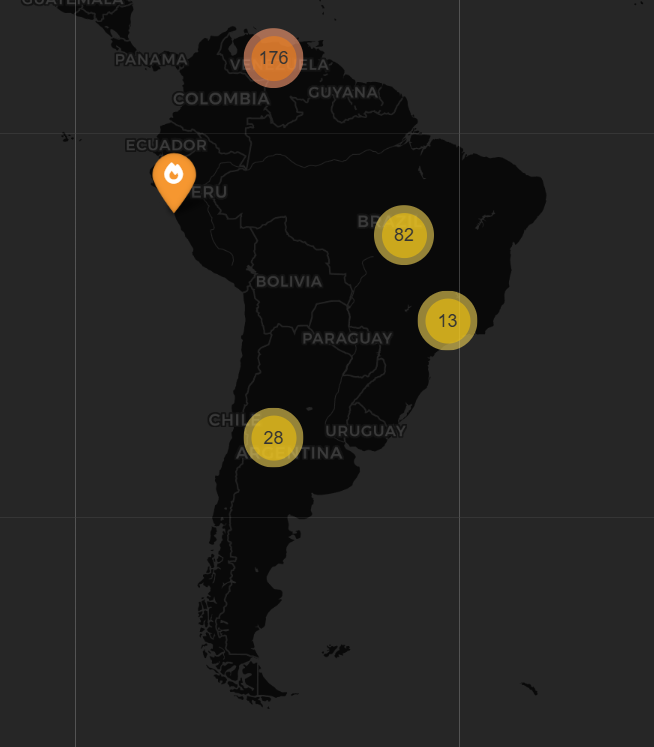

300 fires aggregated over South America, when hovering over the fires, the brightness is indicated

things to change: 
- fire icon to points maybe
- colour of the aggregation, only yellow to red tones, no green
- maybe change background map
- add pop ups with .add child (see https://geopandas.org/en/v1.1.0/gallery/plotting_with_folium.html)

- NA handling, if I'm not using the sample method

next up, try to create a heat map to have another visualisation

#### Basic Heat Map for current data

no toggle on / off feature, no legend

In [9]:
# use instructions from GeoPandas website

from folium import plugins

sa_heatmap1 = folium.Map(location = [-15, -60], zoom_start = 3, tiles = "CartoDB DarkMatter")

heat_data = [[point.y, point.x] for point in gdf_fire.geometry]
plugins.HeatMap(heat_data).add_to(sa_heatmap1)

sa_heatmap1.save("heatmap1.html")



#### Professional Heat Map

with toggle on / off
change transparency of heatmap (lower it a bit)
legend

##### html script for legend

In [16]:
legend_html = """
<div style = "position: fixed;
bottom: 50px; 
left: 50px;
width: 180px; 
height: 120px;
background-color: white;
z-index:9999;
font-size:14px;
padding: 10px;
border: 2px solid grey;
">

<b>Fire Brightness Legend</b><br>
<i style="background:#ffffcc;width:20px;height:10px;float:left;margin-right:8px;"></i> Low<br>

<i style="background:#feb24c;width:20px;height:10px;float:left;margin-right:8px;"></i> Medium<br>

<i style="background:#f03b20;width:20px;height:10px;float:left;margin-right:8px;"></i> High<br>

<i style="background:#bd0026;width:20px;height:10px;float:left;margin-right:8px;"></i> Extreme

</div>
"""

In [ ]:

from folium import plugins
import branca.colormap as cm #branca for legend

sa_heatmap2 = folium.Map(location = [-15, -60], zoom_start = 3, tiles = "CartoDB DarkMatter")

# create heatmap using brightness values and norm it, so it is comparable
# norm brighntess values; see cartography modules for reasoning again
max_brightness = gdf_fire["bright_ti4"].max()

# choose value for heatmap, my heatmap should show the intensity of the fires

heat_data = [[row.geometry.y, row.geometry.x, row["bright_ti4"]/max_brightness]
            for idx, row in gdf_fire.iterrows()]



# heat map
plugins.HeatMap(
    heat_data,
    radius = 12, # size of the heat points
    blur = 8, 
    min_opacity = 0.5, 
    max_zoom = 6
    ).add_to(sa_heatmap2)



## html script for legend
legend_html = """
<div style = "position: fixed;
bottom: 50px; 
left: 50px;
width: 180px; 
height: 120px;
background-color: white;
z-index:9999;
font-size:14px;
padding: 10px;
border: 2px solid grey;
">

<b>Fire Brightness Legend</b><br>
<i style="background:#ffffcc;width:20px;height:10px;float:left;margin-right:8px;"></i> Low<br>

<i style="background:#feb24c;width:20px;height:10px;float:left;margin-right:8px;"></i> Medium<br>

<i style="background:#f03b20;width:20px;height:10px;float:left;margin-right:8px;"></i> High<br>

<i style="background:#bd0026;width:20px;height:10px;float:left;margin-right:8px;"></i> Extreme

</div>
"""

sa_heatmap2.get_root().html.add_child(folium.Element(legend_html))




folium.LayerControl().add_to(sa_heatmap2)

sa_heatmap2.save("heatmap2.html")

##### mit Brightness normiert

In [ ]:
## colour legend
# YlOrRd = colormap
# _09 = 9 color classes from column ["bright_ti4].min value to column ["bright_ti4"].max value from gdf_fire
colormap = cm.linear.YlOrRd_09.scale(gdf_fire["bright_ti4"].min(), gdf_fire["bright_ti4"].max())
colormap.caption = "Fire Brightness (TI4)"
colormap.add_to(sa_heatmap2)  


AttributeError: 'list' object has no attribute 'head'

intensity * fläche dann aufsummieren

#### heat map with not continuous legend

In [ ]:

from folium import plugins
import branca.colormap as cm #branca for legend

sa_heatmap3 = folium.Map(location = [-15, -60], zoom_start = 3, tiles = "CartoDB DarkMatter")

# create heatmap using brightness values and norm it, so it is comparable
# norm brighntess values; see cartography modules for reasoning again
max_brightness = gdf_fire["bright_ti4"].max()

# choose value for heatmap, my heatmap should show the intensity of the fires

heat_data = [[row.geometry.y, row.geometry.x, row["bright_ti4"]/max_brightness]
            for idx, row in gdf_fire.iterrows()]

## what brightness values do I have? -> analyse heat data and maybe adjust color gradient
gradient = {
    0.0: "#ffffcc",
    0.2: "#ffeda0",
    0.4: "#feb24c",
    0.6: "#fd8d3c",
    0.8: "#f03b20",
    1.0: "#bd0026"
}



# heat map
plugins.HeatMap(
    heat_data,
    radius = 12, # size of the heat points
    blur = 6, 
    min_opacity = 0.5, 
    
    gradient = gradient
    ).add_to(sa_heatmap3)



## html script for legend
legend_html = """
<div style = "position: fixed;
bottom: 50px; 
left: 50px;
width: 150px; 
height: 180px;
background-color: white;
z-index:9999;
font-size:14px;
padding: 10px;
border: 2px solid grey;
">

<b>Fire Brightness Legend</b><br>
<i style="background:#ffffcc;width:20px;height:10px;float:left;margin-right:8px;"></i> Low<br>

<i style="background:#feb24c;width:20px;height:10px;float:left;margin-right:8px;"></i> Medium<br>

<i style="background:#f03b20;width:20px;height:10px;float:left;margin-right:8px;"></i> High<br>

<i style="background:#bd0026;width:20px;height:10px;float:left;margin-right:8px;"></i> Extreme

</div>
"""

sa_heatmap3.get_root().html.add_child(folium.Element(legend_html))




folium.LayerControl().add_to(sa_heatmap3)

sa_heatmap3.save("heatmap3.html")

In [ ]:

from folium import plugins
import branca.colormap as cm #branca for legend

sa_heatmap4 = folium.Map(location = [-15, -60], zoom_start = 3, tiles = "CartoDB DarkMatter")

# create heatmap using brightness values and norm it, so it is comparable
# norm brighntess values; see cartography modules for reasoning again
max_brightness = gdf_fire["bright_ti4"].max()

# choose value for heatmap, my heatmap should show the intensity of the fires

heat_data = [[row.geometry.y, row.geometry.x, row["bright_ti4"]/max_brightness]
            for idx, row in gdf_fire.iterrows()]

## what brightness values do I have? -> analyse heat data and maybe adjust color gradient
gradient = {
    0.0: "#ffffcc",
    0.2: "#ffeda0",
    0.4: "#feb24c",
    0.6: "#fd8d3c",
    0.8: "#f03b20",
    1.0: "#bd0026"
}



# heat map
plugins.HeatMap(
    heat_data,
    radius = 12, # size of the heat points
    blur = 6, 
    min_opacity = 0.5, 
    
    gradient = gradient
    ).add_to(sa_heatmap4)



## html script for continuous legend
legend_html = """
<div style = "position: fixed;
bottom: 50px; 
left: 50px;
width: 250px; 
height: 80px;
background-color: white;
z-index:9999;
font-size:14px;
padding: 10px;
border: 2px solid grey;
">

<b>Fire Brightness Legend</b><br>

<div style="
height: 15px;
background: linear-gradient(to right, #ffffcc, #ffeda0, #feb24c, #fd8d3c, #f03b20, #bd0026);
"></div>

<div style="display:flex; justify-content:space-between;">
<span>{min_b:.0f}</span>
<span>{max_b:.0f}</span>
</div>


</div>
"""

sa_heatmap4.get_root().html.add_child(folium.Element(legend_html))



folium.LayerControl().add_to(sa_heatmap4)



sa_heatmap4.save("heatmap4.html")

**things to improve**

correct legend so it doesn't show {min_b:.0f} and {max_b:.0f}

#### chat gpt solution for toggle on and off legend together with map

include this if time allows

In [ ]:
import folium
from folium import plugins
import branca.colormap as cm

# Base map
sa_heatmap2 = folium.Map(
    location=[-15, -60],
    zoom_start=3,
    tiles="CartoDB DarkMatter"
)

# FeatureGroup (WICHTIG!)
fire_layer = folium.FeatureGroup(name="Fire Heatmap")

# -----------------------------
# Heatmap data
# -----------------------------
max_b = gdf_fire["bright_ti4"].max()

heat_data = [
    [row.geometry.y, row.geometry.x, row["bright_ti4"] / max_b]
    for _, row in gdf_fire.iterrows()
]

plugins.HeatMap(
    heat_data,
    radius=12,
    blur=8,
    min_opacity=0.5,
    max_zoom=6
).add_to(fire_layer)

# -----------------------------
# Add layer to map
# -----------------------------
fire_layer.add_to(sa_heatmap2)

# -----------------------------
# Legend (inside SAME layer)
# -----------------------------
legend_html = f"""
<div id="legend" style="
position: fixed;
bottom: 50px;
left: 50px;
width: 250px;
background: white;
padding:10px;
border:2px solid grey;
z-index:9999;
">

<b>Fire Brightness</b><br>

<div style="
height: 12px;
background: linear-gradient(to right,
#ffffcc, #ffeda0, #feb24c, #f03b20, #bd0026);
"></div>

<div style="display:flex; justify-content:space-between;">
<span>{gdf_fire["bright_ti4"].min():.0f}</span>
<span>{gdf_fire["bright_ti4"].max():.0f}</span>
</div>

</div>
"""

legend = folium.Element(legend_html)

# Attach legend to same feature group
fire_layer.get_root().html.add_child(legend)

# -----------------------------
# Layer control
# -----------------------------
folium.LayerControl().add_to(sa_heatmap2)

sa_heatmap2.save("heatmap2.html")

#### analyse brightness data for a well-fitted gradient 

create separate lists, which can be looked at to inspect brightness data for gradient

### Further Ideas

**Generate an interactive choropleth in a single command**

interactive_map = quarters_4326.explore(
 column="parking_density", # The column dictating the color
 cmap="viridis", # The colormap
 alpha=0.6, # Transparency of the polygons
 tiles="CartoDB Positron No Labels", # A clean basemap
 legend_kwds={"caption": "Parking locations / km²"}, # Set
legend title) 

*see p. 61 of summary (part2) under explore()*


**The Hybrid Approach (The Best of Both Worlds):**

You do
not have to choose just one! You can actually combine the
speed of .explore() with the structural control of Folium. By initializing a blank folium.Map() first, you can pass it to the m parameter inside .explore().
This is the perfect approach for building Multi-Layer Dashboards. It allows you to rapidly add multiple GeoDataFrames to
the exact same canvas and easily append a LayerControl menu: